In [37]:
import carbspec as cs
from carbspec.spectro import Spectrum
from carbspec.spectro import mixture
from carbspec import dye
from carbspec.helpers import calc_pH_Tris

import numpy as np
import matplotlib.pyplot as plt

In [3]:
path = '/home/oscar/CamDrive/Projects/BuildingShells/pH_TA/data_pH/'

In [33]:
files = [
    'MCP_20241209_115202_TRIS_10ml_50ul_new.pkl',
    'MCP_20241209_115216_TRIS_10ml_50ul_new.pkl',
    'MCP_20241209_115429_TRIS_10ml_50ul_new.pkl',
    'MCP_20241209_115937_TRIS_10ml_50ul_new.pkl',
    'MCP_20241209_120019_TRIS_10ml_50ul_new.pkl',
    'MCP_20241209_120053_TRIS_15ml_100ul_new.pkl',
    'MCP_20241209_120429_TRIS_15ml_100ul_new.pkl',
]

In [34]:
spectra = [Spectrum.load(path + '/pkl/' + f) for f in files]

In [69]:
ps = []
for s in spectra:
    p, _ = mixture.unmix_spectra(s.wv, s.absorbance, 'MCP')
    ps.append(p)
ps = np.array(ps)
f = ps[:,1] / ps[:,0]


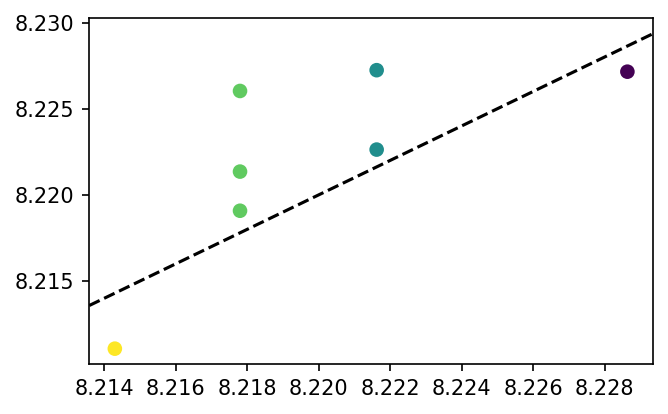

In [ ]:

temps = []
for s in spectra:
    temps.append(s.temp)
temps = np.array(temps)

K = dye.K_handler('MCP', temps, 35)

tris_pH = calc_pH_Tris(35, temps)

calc_pH = mixture.pH_from_F(f, K + 3e-10)

plt.scatter(tris_pH, calc_pH, c=temps)
ax = plt.gca()

ax.set_xlim(ax.get_xlim())
ax.plot(ax.get_xlim(), ax.get_xlim(), 'k--')